In [1]:
import math

from einops import rearrange
from matplotlib import pyplot as plt
import nibabel as nib
import numpy as np

import flat_mae.nisc as nisc

This notebook contains rough code for patchifying sparse MNI cortex data. The pipeline is:

1. extract cortex mask (schaefer 400)
2. patchify with 8 x 8 x 8 patches
3. drop patches that have less than 10% data
4. construct indices to gather masked data into patch sequence, and reverse

In [2]:
roi_path = nisc.fetch_schaefer(400, space="mni")
print(roi_path)

/home/connor/.cache/parcellations/Schaefer2018_400Parcels_17Networks_order_FSLMNI152_2mm.nii.gz


In [3]:
img = nib.load(roi_path)
mask = np.ascontiguousarray(img.get_fdata().T)  # nb transpose to c contiguous [Z, Y, X] = [D, H, W]
mask = mask > 0
print(mask.shape, mask.sum())

(91, 109, 91) 132032


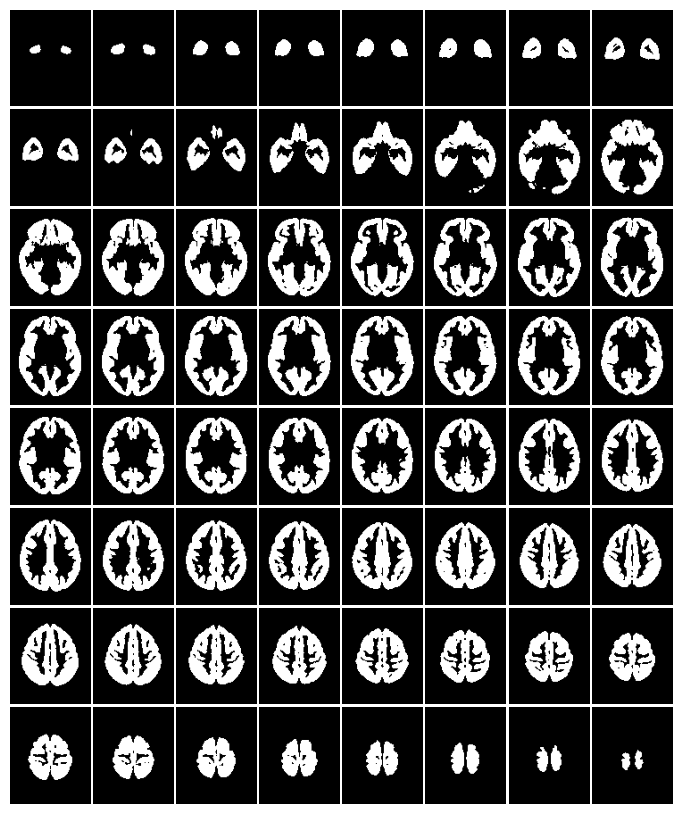

In [4]:
H, W = mask.shape[1:]
ploth = 1.0
plotw = (W / H) * ploth
nr = 8
nc = 8
f, axs = plt.subplots(nr, nc, figsize=(nc * plotw, nr * ploth))
axs = axs.flatten()

offset = 12
step = 1

for ii, ax in enumerate(axs):
    plt.sca(ax)
    maskslc = mask[step * ii + offset]
    plt.imshow(maskslc, vmin=0, vmax=1, origin="lower", cmap="gray")
    plt.axis("off")

plt.tight_layout(pad=0.2)

In [5]:
def pad_to_multiple(x: np.ndarray, mult: int):
    shape = x.shape
    pad_width = []
    for dim in shape:
        if dim % mult == 0:
            pad_width.append((0, 0))
        else:
            pad_width.append((0, mult * math.ceil(dim / mult) - dim))

    x = np.pad(x, pad_width)
    return x

In [6]:
patch_size = 8
# mask_pad = pad_to_multiple(mask, patch_size)
# thx claude
mask_pad = np.pad(mask, [(0, -d % patch_size) for d in mask.shape])
print(mask.shape)
print(mask_pad.shape)
print([dim // patch_size for dim in mask_pad.shape])

(91, 109, 91)
(96, 112, 96)
[12, 14, 12]


In [7]:
D, H, W = mask_pad.shape
p = patch_size

mask_blocks = rearrange(
    mask_pad,
    "(d p) (h q) (w r) -> (d h w) (p q r)",
    p=p,
    q=p,
    r=p,
)
print(mask_blocks.shape)

(2016, 512)


In [8]:
threshold = 0.10
block_mask = mask_blocks.mean(axis=1) > threshold
print(block_mask.sum())

block_counts = mask_blocks[block_mask].sum(axis=1)
print(
    block_counts.min(),
    round(block_counts.mean()),
    round(np.median(block_counts)),
    block_counts.max(),
    block_counts.sum(),
)

466
53 278 280 510 129748


In [9]:
# construct array of shape (n_blocks, dim) that contains the indices back into the
# masked data, shape (T, 132032)
mask_pad_ids = mask_pad * np.cumsum(mask_pad).reshape(mask_pad.shape) - 1

mask_pad_ids_blocks = rearrange(
    mask_pad_ids,
    "(w p) (h q) (d r) -> (w h d) (p q r)",
    p=p,
    q=p,
    r=p,
)
mask_pad_ids_blocks = mask_pad_ids_blocks[block_mask]
print(mask_pad_ids_blocks.shape, (mask_pad_ids_blocks >= 0).sum())

(466, 512) 129748


In [10]:
ids_restore = np.argsort(mask_pad_ids_blocks[mask_pad_ids_blocks >= 0])
restore_mask = np.zeros(132032, dtype=bool)
restore_mask[mask_pad_ids_blocks.flatten()] = True
print(ids_restore.shape, restore_mask.shape, restore_mask.sum())

(129748,) (132032,) 129748


In [11]:
x = np.random.randn(16, 132032)
x = x * restore_mask

x_blocks = x[:, mask_pad_ids_blocks]
print(x_blocks.shape)

x_restore = np.zeros_like(x)
x_restore[:, restore_mask] = x_blocks[:, mask_pad_ids_blocks >= 0][:, ids_restore]
assert np.all(x == x_restore)

(16, 466, 512)


In [12]:
assert ((mask_pad_ids >= 0) == mask_pad).all()
assert (mask_pad_ids[mask_pad] == np.arange(mask_pad.sum())).all()

In [13]:
mask_pad_ids_2 = np.full_like(mask_pad, -1, dtype=np.int64)
mask_pad_ids_2[mask_pad] = np.arange(mask_pad.sum())

In [14]:
np.all(mask_pad_ids == mask_pad_ids_2)

True